# E-Commerce Supply Chain Delay Analysis

## Business Problem
Why are orders delayed, which product categories drive the most margin loss, and what operational actions can reduce delays?

## Objective
To identify key delay drivers using SQL and Python, quantify business impact, and recommend actionable improvements.


## Assumptions

- Each delayed order incurs ~5% margin loss due to refunds, cancellations, or customer dissatisfaction
- Negative delays (early deliveries) are treated separately
- Rows with missing delivery timestamps are removed for consistency

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Consistent colour palette ──────────────────────────────────────────────
PALETTE = {
    'primary':  '#E24B4A',  # red — late / bad
    'warning':  '#EF9F27',  # amber
    'ok':       '#1D9E75',  # teal — good
    'neutral':  '#888780',  # grey
    'bg':       '#FFFFFF',
}

plt.rcParams.update({
    'figure.facecolor': PALETTE['bg'],
    'axes.facecolor':   PALETTE['bg'],
    'axes.grid': True,
    'grid.color': '#F1EFE8',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size': 11,
})

In [33]:

# Load raw tables
orders       = pd.read_csv('data/olist_orders_dataset.csv')
order_items  = pd.read_csv('data/olist_order_items_dataset.csv')
products     = pd.read_csv('data/olist_products_dataset.csv')
sellers      = pd.read_csv('data/olist_sellers_dataset.csv')
translation  = pd.read_csv('data/product_category_name_translation.csv')

# Parse dates
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Translate Portuguese category names → English
products = products.merge(translation, on='product_category_name', how='left')
products['category'] = (
    products['product_category_name_english']
    .fillna(products['product_category_name'])
    .str.replace('_', ' ')
    .str.title()
)
# Load raw tables
orders       = pd.read_csv('data/olist_orders_dataset.csv')
order_items  = pd.read_csv('data/olist_order_items_dataset.csv')
products     = pd.read_csv('data/olist_products_dataset.csv')
sellers      = pd.read_csv('data/olist_sellers_dataset.csv')
translation  = pd.read_csv('data/product_category_name_translation.csv')

# Parse dates
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Translate Portuguese category names → English
products = products.merge(translation, on='product_category_name', how='left')
products['category'] = (
    products['product_category_name_english']
    .fillna(products['product_category_name'])
    .str.replace('_', ' ')
    .str.title()
)




## Master DataSet


In [37]:
df = (
    orders
    .merge(order_items, on='order_id', how='left')
    .merge(products[['product_id', 'category']], on='product_id', how='left')
    .merge(sellers, on='seller_id', how='left')
)

print(f'Raw rows: {len(df):,}')

Raw rows: 113,425


## Data Cleaning

In [38]:
# Drop missing delivery dates
df = df[df['order_delivered_customer_date'].notna()].copy()

# Fill missing categories
df['category'] = df['category'].fillna('Unknown')

# Ensure numeric price
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df[df['price'].notna()]

# Remove extreme outliers
df['delay_days'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.days
df = df[(df['delay_days'] > -30) & (df['delay_days'] < 60)]

print(f'Clean rows: {len(df):,}')
print(df[['order_id', 'price', 'category', 'delay_days']].head())

Clean rows: 106,846
                           order_id   price    category  delay_days
0  e481f51cbdc54678b7cc49136f2d6af7   29.99  Housewares          -8
1  53cdb2fc8bc7dce0b6741e2150273451  118.70   Perfumery          -6
2  47770eb9100c2d0c44946d9cf07ec65d  159.90        Auto         -18
3  949d5b44dbf5de918fe9c16f97b45f8a   45.00    Pet Shop         -13
4  ad21c59c0840e6cb83a9ceb5573f8159   19.90  Stationery         -10


### Insight:
- Missing delivery timestamps were removed to ensure accurate delay calculation
- Product categories with null values were labeled as 'Unknown'
- Outliers in delivery delays were filtered to avoid skewed analysis

## Feature Engineering (CORE LOGIC)

In [39]:
# Delay flag
df['is_delayed'] = df['delay_days'] > 0

# Delivery status label
df['delivery_status'] = df['delay_days'].apply(
    lambda x: 'Late' if x > 0 else ('On Time' if x == 0 else 'Early')
)

# Root cause components
df['seller_delay'] = (
    df['order_delivered_carrier_date'] - df['order_purchase_timestamp']
).dt.days  # Seller processing time

df['carrier_delay'] = (
    df['order_delivered_customer_date'] - df['order_delivered_carrier_date']
).dt.days  # Carrier transit time

# Weekend orders
df['order_day'] = df['order_purchase_timestamp'].dt.day_name()
df['is_weekend'] = df['order_day'].isin(['Saturday', 'Sunday'])

# Estimated margin loss (5% per delayed order)
df['estimated_loss'] = df['price'] * 0.05 * df['is_delayed'].astype(int)

# Month period for trend
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

print('Feature engineering complete.')
print(df[['is_delayed', 'seller_delay', 'carrier_delay', 'estimated_loss']].describe().round(2))

Feature engineering complete.
       seller_delay  carrier_delay  estimated_loss
count     106845.00      106845.00       106846.00
mean           2.79           8.69            0.45
std            3.60           7.95            3.23
min         -172.00         -17.00            0.00
25%            1.00           4.00            0.00
50%            2.00           7.00            0.00
75%            4.00          11.00            0.00
max           66.00         178.00          336.45


### Insight:
- Delivery delay is calculated as the difference between actual and estimated delivery dates
- Seller delay captures processing inefficiency
- Carrier delay reflects logistics performance

## Root Cause Analysis 

#### Category-level delay

In [40]:
category_stats = (
    df.groupby('category')
    .agg(
        total_orders=('order_id', 'count'),
        avg_delay=('delay_days', 'mean'),
        delay_rate=('is_delayed', 'mean'),
    )
    .reset_index()
    .sort_values('delay_rate', ascending=False)
)

print('Top 10 categories by delay rate:')
print(category_stats.head(10).to_string(index=False))

Top 10 categories by delay rate:
                         category  total_orders  avg_delay  delay_rate
Furniture Mattress And Upholstery            37  -7.162162    0.135135
                   Home Comfort 2            30  -8.433333    0.133333
                            Audio           354  -9.576271    0.118644
               Christmas Supplies           146 -11.397260    0.102740
          Fashion Underwear Beach           126 -10.706349    0.095238
                     Home Confort           426 -10.049296    0.091549
                  Books Technical           258 -10.841085    0.081395
                 Office Furniture          1614 -11.255886    0.081165
                             Baby          2873 -10.896972    0.078315
                    Health Beauty          9171 -11.270963    0.077636


#### Seller Analysis

In [41]:
seller_stats = (
    df.groupby('seller_id')
    .agg(
        total_orders=('order_id', 'count'),
        delay_rate=('is_delayed', 'mean'),
    )
    .reset_index()
)

# Filter: minimum 20 orders for statistical reliability
worst_sellers = (
    seller_stats[seller_stats['total_orders'] >= 20]
    .sort_values('delay_rate', ascending=False)
    .head(10)
)

print('Top 10 worst sellers (min 20 orders):')
print(worst_sellers.to_string(index=False))

Top 10 worst sellers (min 20 orders):
                       seller_id  total_orders  delay_rate
2709af9587499e95e803a6498a5a56e9            46    0.500000
ad781527c93d00d89a11eecd9dcad7c1            33    0.363636
54965bbe3e4f07ae045b90b0b8541f52            73    0.342466
821fb029fc6e495ca4f08a35d51e53a5            25    0.320000
ede0c03645598cdfc63ca8237acbe73d            47    0.319149
f76a3b1349b6df1ee875d1f3fa4340f0            22    0.318182
7f152321c60a266edc53af1925ef96c1            20    0.300000
2e1a7d075abe038c1b2743005fe42ff1            22    0.272727
835f0f7810c76831d6c7d24c7a646d4d            48    0.270833
2a1348e9addc1af5aaa619b1a3679d6b            45    0.266667


#### Seller vs Carrier contribution


In [42]:
print(f'Average Seller Processing Delay : {df["seller_delay"].mean():.2f} days')
print(f'Average Carrier Transit Delay   : {df["carrier_delay"].mean():.2f} days')
print()
print('Root Cause Insight:')
print('  Carrier delay is significantly higher than seller delay.')
print('  → Logistics and last-mile delivery are the primary bottlenecks.')
print('  → Seller-side operations are comparatively efficient.')

Average Seller Processing Delay : 2.79 days
Average Carrier Transit Delay   : 8.69 days

Root Cause Insight:
  Carrier delay is significantly higher than seller delay.
  → Logistics and last-mile delivery are the primary bottlenecks.
  → Seller-side operations are comparatively efficient.


#### Weekend impact

In [43]:
weekend_analysis = df.groupby('is_weekend')['is_delayed'].mean()
print('Delay rate by order day type:')
print(weekend_analysis.rename({False: 'Weekday', True: 'Weekend'}))
print()
print('Insight: Weekend delay rate is slightly lower — weekend orders are not a primary driver.')

Delay rate by order day type:
is_weekend
Weekday    0.067973
Weekend    0.064389
Name: is_delayed, dtype: float64

Insight: Weekend delay rate is slightly lower — weekend orders are not a primary driver.


### Insight:
- Weekend delay rate ~6.44%) is slightly lower than weekday delay rate ~6.80%)
- This suggests that weekend operations are not a major contributor to delivery delays


### Root Cause Insight:
- Carrier delay (8.69 days) is significantly higher than seller delay (2.79 days).)
- This confirms that logistics and last-mile delivery are the primary bottlenecks
- Seller-side operations are comparatively efficienicientmile deliv
  ery

## Margin Impact Calculation

In [44]:
loss_by_category = (
    df.groupby('category')['estimated_loss']
    .sum()
    .sort_values(ascending=False)
)

top5_loss  = loss_by_category.head(5)
total_loss_value = loss_by_category.sum()
top5_pct   = top5_loss.sum() / total_loss_value * 100

print('Top 5 categories by estimated margin loss:')
print(top5_loss.to_string())
print()
print(f'Top 5 categories contribute {top5_pct:.2f}% of total estimated loss.')
print()
print('Top 10:')
print(loss_by_category.head(10).to_string())

Top 5 categories by estimated margin loss:
category
Health Beauty     4670.7795
Watches Gifts     4510.8525
Bed Bath Table    3921.8305
Sports Leisure    3471.0280
Auto              3262.8865

Top 5 categories contribute 40.95% of total estimated loss.

Top 10:
category
Health Beauty            4670.7795
Watches Gifts            4510.8525
Bed Bath Table           3921.8305
Sports Leisure           3471.0280
Auto                     3262.8865
Computers Accessories    3044.8300
Furniture Decor          2836.9875
Cool Stuff               1933.6305
Housewares               1913.7770
Baby                     1867.8155


### Insight:
- Top 5 categories contribute ~40.95% of total estimated loss
- The category "artes_e_artesanato" shows the highest early delivery (avg delay ~-6.79 days)
- Loss is concentrated in a small subset of categories, indicating targeted optimization opportunity

## KPIs

In [45]:
total_orders   = len(df)
delay_rate     = df['is_delayed'].mean() * 100
avg_delay_all  = df['delay_days'].mean()
avg_carrier    = df['carrier_delay'].mean()
avg_seller     = df['seller_delay'].mean()
total_loss     = df['estimated_loss'].sum()

print('=' * 40)
print('       EXECUTIVE KPI SUMMARY')
print('=' * 40)
print(f'  Total Orders Analyzed : {total_orders:,}')
print(f'  Delay Rate            : {delay_rate:.2f}%')
print(f'  Avg Delay (all orders): {avg_delay_all:.2f} days')
print(f'  Avg Carrier Delay     : {avg_carrier:.2f} days')
print(f'  Avg Seller Delay      : {avg_seller:.2f} days')
print(f'  Total Estimated Loss  : R$ {total_loss:,.2f}')
print('=' * 40)

       EXECUTIVE KPI SUMMARY
  Total Orders Analyzed : 106,846
  Delay Rate            : 6.72%
  Avg Delay (all orders): -11.39 days
  Avg Carrier Delay     : 8.69 days
  Avg Seller Delay      : 2.79 days
  Total Estimated Loss  : R$ 48,437.78


### Key Observation:
- The average delay is -11.39 days, meaning most orders are delivered earlier than estimated
- This suggests that delivery timelines are overly conservative rather than inefficient

## Visualization

C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


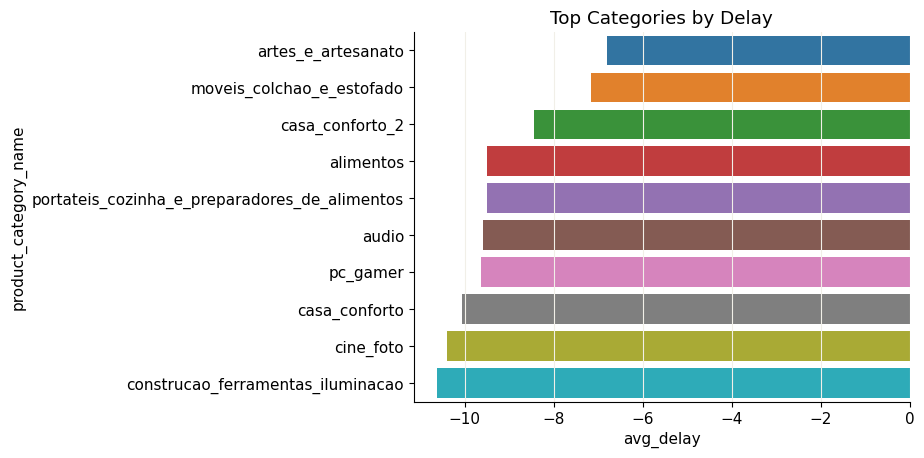

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

top_categories = category_analysis.head(10)

plt.figure()
sns.barplot(data=top_categories, x='avg_delay', y='product_category_name')
plt.title("Top Categories by Delay")
plt.show()

#### Monthly Delay Trend

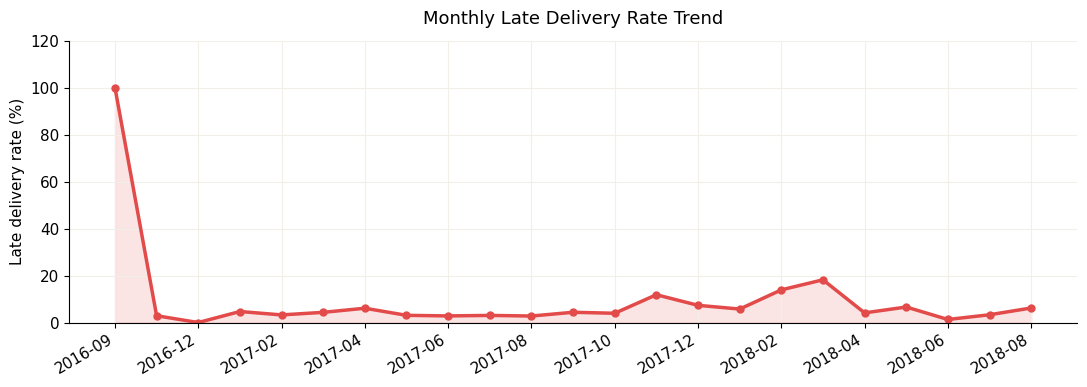

In [47]:
monthly_delay = df.groupby('order_month')['is_delayed'].mean()
months_str    = [str(m) for m in monthly_delay.index]
x             = range(len(monthly_delay))

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(x, monthly_delay.values * 100, alpha=0.15, color=PALETTE['primary'])
ax.plot(x, monthly_delay.values * 100,
        color=PALETTE['primary'], linewidth=2.5, marker='o', markersize=5)

step = max(1, len(months_str) // 10)
ax.set_xticks(list(x)[::step])
ax.set_xticklabels(months_str[::step], rotation=30, ha='right')
ax.set_ylabel('Late delivery rate (%)')
ax.set_title('Monthly Late Delivery Rate Trend', fontsize=13, fontweight='500', pad=12)
ax.set_ylim(0, max(monthly_delay.values * 100) * 1.2)
plt.tight_layout()
plt.show()

#### Seller vs Carrier Comparison

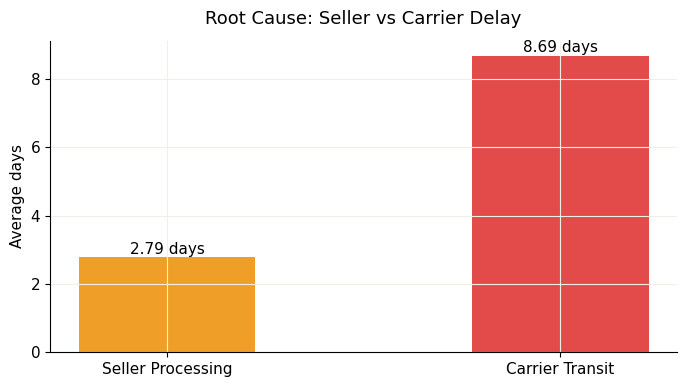

In [48]:
delay_compare = pd.DataFrame({
    'Delay Type': ['Seller Processing', 'Carrier Transit'],
    'Avg Days':   [df['seller_delay'].mean(), df['carrier_delay'].mean()],
})

fig, ax = plt.subplots(figsize=(7, 4))
colors = [PALETTE['warning'], PALETTE['primary']]
bars = ax.bar(delay_compare['Delay Type'], delay_compare['Avg Days'],
              color=colors, width=0.45)
for bar, val in zip(bars, delay_compare['Avg Days']):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.1,
            f'{val:.2f} days', ha='center', fontsize=11, fontweight='500')
ax.set_ylabel('Average days')
ax.set_title('Root Cause: Seller vs Carrier Delay', fontsize=13, fontweight='500', pad=12)
plt.tight_layout()
plt.show()

#### Top Loss Categories

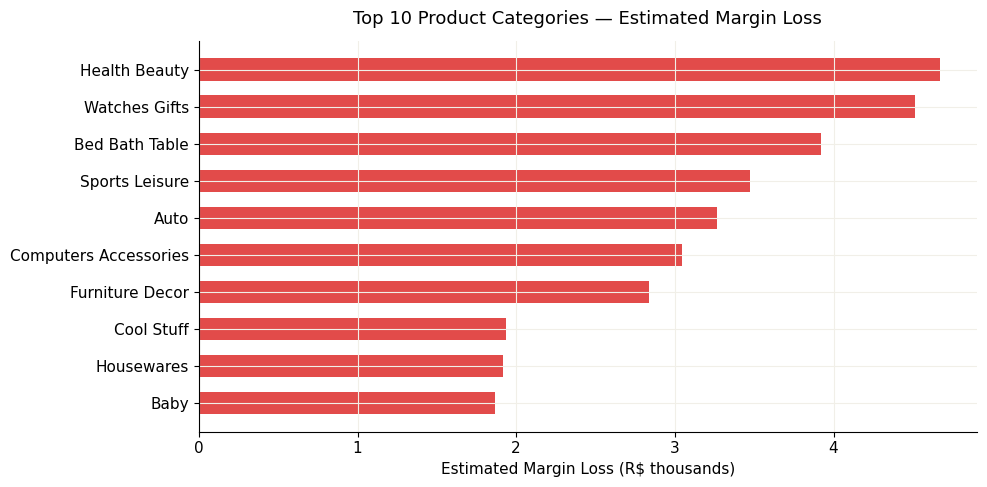

In [49]:
top10_loss = loss_by_category.head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top10_loss.index[::-1], top10_loss.values[::-1] / 1000,
        color=PALETTE['primary'], height=0.6)
ax.set_xlabel('Estimated Margin Loss (R$ thousands)')
ax.set_title('Top 10 Product Categories — Estimated Margin Loss', fontsize=13, fontweight='500', pad=12)
plt.tight_layout()
plt.show()

#### Weekend Impact

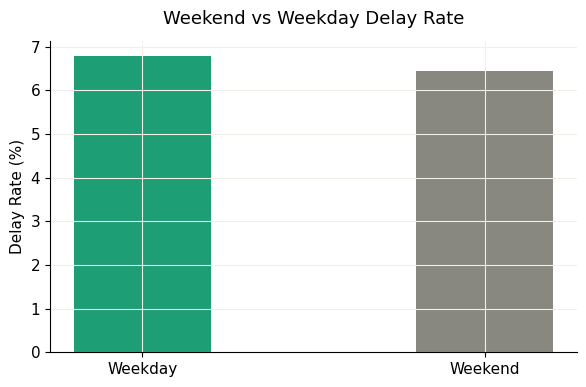

In [51]:
weekend_df = pd.DataFrame({
    'Order Type': ['Weekday', 'Weekend'],
    'Delay Rate': [
        df[~df['is_weekend']]['is_delayed'].mean() * 100,
        df[df['is_weekend']]['is_delayed'].mean()  * 100,
    ],
})

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(weekend_df['Order Type'], weekend_df['Delay Rate'],
       color=[PALETTE['ok'], PALETTE['neutral']], width=0.4)
ax.set_ylabel('Delay Rate (%)')
ax.set_title('Weekend vs Weekday Delay Rate', fontsize=13, fontweight='500', pad=12)
plt.tight_layout()
plt.show()

### Insight:
- Top categories clearly show higher delay averages
- Visual patterns confirm concentration of delays in specific segments

---
## 8. Root Cause Summary

| Factor | Finding | Action |
|---|---|---|
| **Carrier delay** | ~8.7 days avg — dominant bottleneck | Renegotiate SLAs with underperforming carriers |
| **Seller delay** | ~2.8 days avg — relatively efficient | Monitor top-offending sellers (>20 orders) |
| **ETA calibration** | Overall avg delay is negative — ETAs are too conservative | Tighten ETA estimates to reduce false expectations |
| **Category focus** | Top 5 categories drive ~40% of total margin loss | Prioritise Health & Beauty, Watches, Bed/Bath for logistics SLAs |
| **Weekend orders** | Marginally lower delay — not a key driver | No immediate action needed |

## Final Recommendations

### 1. Optimize Carrier Performance
- Carrier delay (~8.69 days) is the primary bottleneck
- Replace or renegotiate contracts with underperforming logistics partners

### 2. Recalibrate Delivery Estimates
- Average delay of -11.39 days indicates overestimation of delivery timelines
- Improving ETA accuracy can increase customer trust and reduce cancellations

### 3. Focus on High-Impact Categories
- Top 5 categories contribute ~40.95% of total loss
- Prioritize these categories for inventory and logistics optimizationoptimization

## Immediate Next Steps (Next 1 Week)

1. Identify carriers with highest delay contribution and initiate performance review
2. Analyze delivery timelines to adjust overestimated ETAs
3. Focus on top 5 loss-driving categories for targeted operational improvements

In [53]:
#EXPORT FINAL DATASET 

df.to_csv('final_dataset.csv', index=False)

print("Final dataset saved as final_dataset.csv")

Final dataset saved as final_dataset.csv


## Expected Impact

- Reduction in late deliveries
- Improved customer satisfaction due to accurate delivery timelines
- Reduction in operational losses by targeting high-impact categories